In [1]:
# %% Imports
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import windows
import os
%matplotlib widget

plt.rc('font', family='serif')
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', titlesize=16, labelsize=16)
plt.rc('legend', fontsize=14)
plt.rc('figure', titlesize=18)


In [ ]:
"""
Cell 1 -- generate SYNTHETIC TOF data in the SAME wide layout as the real sheet,
so the importer in Cell 2 can be tested on it. Nothing here is a measurement.

Columns written, matching the spreadsheet exactly:
    track speed, PID setting, direction, pmt delay,
    time fit 1 .. time fit 10, sigma 1 .. sigma 10
Times are in ms. "sigma N" is the arrival-peak width for shot N (not the
shot-to-shot scatter). Both are INVENTED noise; replace by taking real data.
"""
import numpy as np
import pandas as pd
from pathlib import Path

# ---------------------------------------------------------------- knobs
CENTROID_JITTER_MS = 0.4     # [NUM?] shot-to-shot scatter of the fitted arrival time
WIDTH_FLOOR_MS     = 0.5     # [NUM?] detection/fit floor on the peak width
SIGMA_V_THERMAL    = 0.0224  # [NUM?] m/s, 1D Cs velocity spread at ~8 uK
N_SHOTS            = 10
PID_SETTING        = 200
SEED               = 20260716

# ------------------------------------------------------------- geometry
G       = 9.81
ALPHA   = 16.0 * np.sqrt(2)          # 16 bounces * sqrt(2) from the 45 deg beams
H_PROBE = 0.25                       # m
V_TRACK_MAX_DOWN = 175.0             # mm/s; above this the cloud clears the tower

def t_cross(v, h=H_PROBE, g=G):
    disc = v**2 - 2*g*h
    root = np.sqrt(np.where(disc > 0, disc, np.nan))
    return (v - root)/g, (v + root)/g          # t_up, t_down  [s]

def dt_dv(v, direction, h=H_PROBE, g=G):
    root = np.sqrt(v**2 - 2*g*h)
    return (1 - v/root)/g if direction == "up" else (1 + v/root)/g

# up- and down-going scans (mm/s)
v_up   = np.array([105,110,120,130,140,150,160,170,175,200,220,240,260,280,300,325], float)
v_down = np.array([105,110,120,130,140,150,160,170,175], float)

rng  = np.random.default_rng(SEED)
rows = []
for direction, vlist in (("up", v_up), ("down", v_down)):
    for vt in vlist:
        if direction == "down" and vt > V_TRACK_MAX_DOWN:
            continue
        v_l  = ALPHA * vt*1e-3
        tu, td = t_cross(v_l)
        t0   = (tu if direction == "up" else td) * 1e3          # model time, ms
        if not np.isfinite(t0):
            continue
        width = np.hypot(abs(dt_dv(v_l, direction))*SIGMA_V_THERMAL*1e3,
                         WIDTH_FLOOR_MS)                          # peak width, ms
        row = {"track speed": vt, "PID setting": PID_SETTING,
               "direction": direction,
               "pmt delay": max(0, round(t0 - 75))}
        for k in range(1, N_SHOTS+1):
            row[f"time fit {k}"] = round(t0 + rng.normal(0, CENTROID_JITTER_MS), 2)
            row[f"sigma {k}"]    = round(width + rng.normal(0, 0.1*width), 2)
        rows.append(row)

cols = (["track speed", "PID setting", "direction", "pmt delay"]
        + [c for k in range(1, N_SHOTS+1) for c in (f"time fit {k}", f"sigma {k}")])
df = pd.DataFrame(rows)[cols]

out = Path("data"); out.mkdir(exist_ok=True)
df.to_csv(out/"tof_synthetic.csv", index=False)
print(f"alpha = {ALPHA:.3f}   cutoff at {H_PROBE*100:.0f} cm = "
      f"{np.sqrt(2*G*H_PROBE)/ALPHA*1e3:.1f} mm/s")
print(f"{len(df)} rows -> {out/'tof_synthetic.csv'}")

alpha = 22.627   cutoff at 24 cm = 96.8 mm/s
25 rows -> data/tof_synthetic.csv


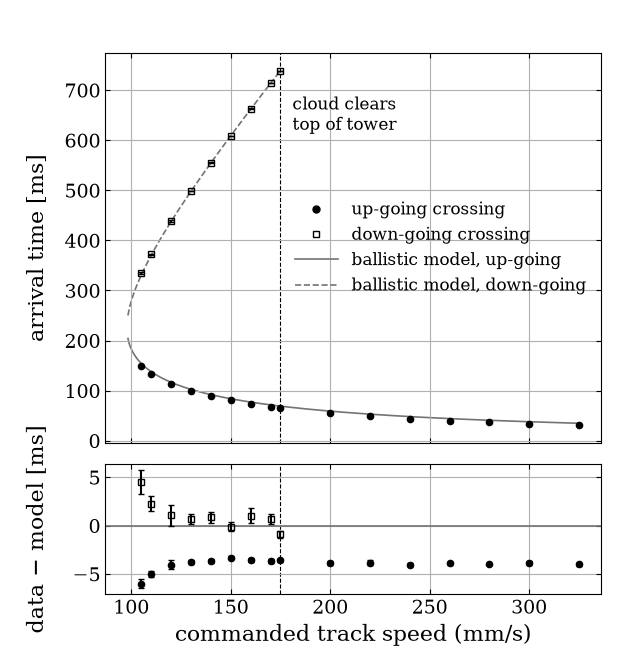

In [47]:
"""
Cell 2 -- read the file, draft the figure.
Top:    arrival time vs commanded track speed, both crossings, kinematic model.
Bottom: residual, data - model, in ms.
Reads the WIDE sheet (track speed | direction | time fit 1..N) and reshapes.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

G       = 9.7997
ALPHA   = 16.0 * np.sqrt(2) * (1 + 0.00)
H_PROBE = 0.250
V_TRACK_MAX_DOWN = 175.0        # x of the "cloud clears tower" marker (annotation only)

# --------------------------------------------------------------- read + reshape
# Point at the real sheet (.csv, or tab-separated .tsv/.txt) or the synthetic file.
DATA_PATH = Path("data")/"TOF_2026_July_16_1536.csv"

_sep = "\t" if DATA_PATH.suffix.lower() in (".tsv", ".txt") else ","
raw  = pd.read_csv(DATA_PATH, sep=_sep)
raw.columns = raw.columns.str.strip()

time_cols = [c for c in raw.columns if c.lower().startswith("time fit")]
df = raw.melt(id_vars=["track speed", "direction", "PID setting", "pmt delay"],
              value_vars=time_cols, var_name="fit", value_name="t_ms")
df["shot"]      = df["fit"].str.extract(r"(\d+)").astype(int)
df = df.rename(columns={"track speed": "v_track_mm_s",
                        "PID setting": "pid",
                        "pmt delay":   "pmt_delay_ms"})
df["direction"] = df["direction"].str.strip().str.lower()
df["t_s"]       = df["t_ms"] / 1e3                       # sheet is ms; model is seconds
df = df.dropna(subset=["t_s"]).reset_index(drop=True)
df = df[~((df.v_track_mm_s == 260) & (df.pid == 200))]

# --- guards: surface the two things that silently corrupt the plot --------------
assert set(df.direction.unique()) <= {"up", "down"}, df.direction.unique()

_dup = (df.groupby(["direction", "v_track_mm_s"])["pid"].nunique()
          .loc[lambda s: s > 1])
if len(_dup):
    print("WARNING: same (direction, track speed) at >1 PID -- these MERGE into one "
          "point. Pick one PID before plotting, e.g.:")
    print("  df = df[~((df.v_track_mm_s == 260) & (df.pid == 200))]")
    print(_dup.to_string(), "\n")

_med = df.groupby(["direction", "v_track_mm_s"])["t_ms"].transform("median")
_bad = df[(df.t_ms - _med).abs() > 0.25*_med]
if len(_bad):
    print("WARNING: arrival times far from their group median (possible typos):")
    print(_bad[["direction", "v_track_mm_s", "shot", "t_ms"]].to_string(index=False), "\n")

# ------------------------------------------------------------------- model
def t_cross(v, h=H_PROBE, g=G):
    disc = v**2 - 2*g*h
    root = np.sqrt(np.where(disc > 0, disc, np.nan))
    return (v - root)/g, (v + root)/g

def t_model(v_track_mm_s, direction):
    tu, td = t_cross(ALPHA * np.asarray(v_track_mm_s, float)*1e-3)
    return tu if direction == "up" else td

# ------------------------------------------------- mean and SEM per setting
g_ = df.groupby(["direction", "v_track_mm_s"])["t_s"]
stat = g_.agg(t_mean="mean", t_sd="std", n="count").reset_index()
stat["t_sem"]  = stat.t_sd #/ np.sqrt(stat.n)            # swap to stat.t_sd for std bars
stat["t_th"]   = [t_model(v, d) for v, d in zip(stat.v_track_mm_s, stat.direction)]
stat["res_ms"] = (stat.t_mean - stat.t_th)*1e3          # data - model

# ------------------------------------------- model curves, spanning the data
V_REACH = np.sqrt(2*G*H_PROBE)/ALPHA*1e3 + 0.5          # cloud just reaches probe
up_speeds = stat.loc[stat.direction == "up",   "v_track_mm_s"]
dn_speeds = stat.loc[stat.direction == "down", "v_track_mm_s"]

vt_up = np.linspace(V_REACH, up_speeds.max(), 500)
tu    = t_model(vt_up, "up")
if len(dn_speeds):
    vt_dn = np.linspace(V_REACH, dn_speeds.max(), 500)
    td    = t_model(vt_dn, "down")

# ------------------------------------------------------------------- plot
fig, (ax, axr) = plt.subplots(
    2, 1, figsize=(6.2, 6.6), sharex=True,
    gridspec_kw=dict(height_ratios=[3, 1], hspace=0.08))
fig.subplots_adjust(left=0.17, right=0.97, top=0.92, bottom=0.10)

MODEL = dict(color="0.45", lw=1.2)
ax.plot(vt_up, tu*1e3, "-", zorder=1, **MODEL)
if len(dn_speeds):
    ax.plot(vt_dn, td*1e3, "--", zorder=1, **MODEL)

mk = dict(up=dict(marker="o", mfc="k"), down=dict(marker="s", mfc="none"))
for d in ("up", "down"):
    s = stat[stat.direction == d]
    if s.empty:
        continue
    for a, y, ye in ((ax,  s.t_mean*1e3, s.t_sem*1e3),
                     (axr, s.res_ms,     s.t_sem*1e3)):
        a.errorbar(s.v_track_mm_s, y, yerr=ye, ls="none", ms=4.5,
                   color="k", mec="k", ecolor="k", capsize=2, zorder=3, **mk[d])

# tower cutoff, annotated in the gap between the two branches
ax.axvline(V_TRACK_MAX_DOWN,  color="k", lw=0.8, zorder=0, linestyle="--")
axr.axvline(V_TRACK_MAX_DOWN, color="k", lw=0.8, zorder=0, linestyle="--")
ax.text(V_TRACK_MAX_DOWN + 6, 650, "cloud clears\ntop of tower",
        fontsize=12, rotation=0, color="k", va="center", ha="left")

axr.axhline(0, color="0.45", lw=1.2)

# legend: make it unmistakable that the grey curves are a model, not a fit
handles = [
    Line2D([], [], ls="none", marker="o", mfc="k",    mec="k", color="k", ms=5,
           label="up-going crossing"),
    Line2D([], [], ls="none", marker="s", mfc="none", mec="k", color="k", ms=5,
           label="down-going crossing"),
    Line2D([], [], ls="-",  label="ballistic model, up-going", **MODEL),
    Line2D([], [], ls="--", label="ballistic model, down-going", **MODEL),
]
ax.legend(handles=handles, frameon=False, fontsize=12, loc="center right",
          handlelength=2.6, title_fontsize=12, alignment="left")

ax.set_ylabel("arrival time [ms]")
axr.set_xlabel("commanded track speed (mm/s)")
axr.set_ylabel("data $-$ model [ms]")
ax.yaxis.set_label_coords(-0.115, 0.5)
axr.yaxis.set_label_coords(-0.115, 0.5)
ax.grid()
axr.grid()
for a in (ax, axr):
    a.tick_params(direction="in", top=True, right=True)

#ax.text(0.5, 0.5, "SYNTHETIC DATA", transform=ax.transAxes,
#        fontsize=48, color="k", alpha=0.2,
#        ha="center", va="center", rotation=30, zorder=10)
#fig.suptitle("SYNTHETIC DATA", fontsize=16, color="k", y=0.965)
#fig.savefig("tof_draft.png", dpi=200)
#print(stat.groupby("direction").res_ms.agg(["mean", "std", "min", "max"]))

In [ ]:
"""
Cell 2 -- read the file, draft the figure.
Top:    arrival time vs commanded track speed, both crossings, kinematic model.
Bottom: residual, data - model, in ms.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

G       = 9.81
ALPHA   = 16.0 * np.sqrt(2)
H_PROBE = 0.25
V_TRACK_MAX_DOWN = 165.0

df = pd.read_csv(Path("data_gitignore")/"tof_synthetic.csv")

def t_cross(v, h=H_PROBE, g=G):
    disc = v**2 - 2*g*h
    root = np.sqrt(np.where(disc > 0, disc, np.nan))
    return (v - root)/g, (v + root)/g

def t_model(v_track_mm_s, direction):
    tu, td = t_cross(ALPHA * np.asarray(v_track_mm_s, float)*1e-3)
    return tu if direction == "up" else td

# ------------------------------------------------- mean and SEM per setting
g_ = df.groupby(["direction", "v_track_mm_s"])["t_s"]
stat = g_.agg(t_mean="mean", t_sd="std", n="count").reset_index()
stat["t_sem"]  = stat.t_sd / np.sqrt(stat.n)
stat["t_th"]   = [t_model(v, d) for v, d in zip(stat.v_track_mm_s, stat.direction)]
stat["res_ms"] = (stat.t_mean - stat.t_th)*1e3          # data - model

# ------------------------------------------------------------------ curves
vt_up  = np.linspace(98.5, 300.0, 500)
vt_dn  = np.linspace(98.5, V_TRACK_MAX_DOWN, 500)
tu     = t_model(vt_up, "up")
td     = t_model(vt_dn, "down")

# ------------------------------------------------------------------- plot
fig, (ax, axr) = plt.subplots(
    2, 1, figsize=(6.2, 6.6), sharex=True,
    gridspec_kw=dict(height_ratios=[3, 1], hspace=0.08))
fig.subplots_adjust(left=0.17, right=0.97, top=0.92, bottom=0.10)

MODEL = dict(color="0.45", lw=1.2)
ax.plot(vt_up, tu*1e3, "-",  zorder=1, **MODEL)
ax.plot(vt_dn, td*1e3, "--", zorder=1, **MODEL)

mk = dict(up=dict(marker="o", mfc="k"), down=dict(marker="s", mfc="none"))
for d in ("up", "down"):
    s = stat[stat.direction == d]
    for a, y, ye in ((ax,  s.t_mean*1e3, s.t_sem*1e3),
                     (axr, s.res_ms,     s.t_sem*1e3)):
        a.errorbar(s.v_track_mm_s, y, yerr=ye, ls="none", ms=4.5,
                   color="k", mec="k", ecolor="k", capsize=2, zorder=3, **mk[d])

# tower cutoff, annotated low, in the gap between the two branches
ax.axvline(V_TRACK_MAX_DOWN,  color="k", lw=0.8, zorder=0, linestyle = '--')
axr.axvline(V_TRACK_MAX_DOWN, color="k", lw=0.8, zorder=0, linestyle = '--')
ax.text(V_TRACK_MAX_DOWN + 6, 650, "cloud clears\ntop of tower",
        fontsize=12, rotation = -0, color="k", va="center", ha="left")

axr.axhline(0, color="0.45", lw=1.2)

# legend: make it unmistakable that the grey curves are a model, not a fit
handles = [
    Line2D([], [], ls="none", marker="o", mfc="k",    mec="k", color="k", ms=5,
           label="up-going crossing"),
    Line2D([], [], ls="none", marker="s", mfc="none", mec="k", color="k", ms=5,
           label="down-going crossing"),
    Line2D([], [], ls="-",  label="ballistic model, up-going", **MODEL),
    Line2D([], [], ls="--", label="ballistic model, down-going", **MODEL),
]
ax.legend(handles=handles, frameon=False, fontsize=12, loc="center right",
          handlelength=2.6,
          title_fontsize=12, alignment="left")

ax.set_ylabel("arrival time [ms]")
axr.set_xlabel("commanded track speed (mm/s)")
axr.set_ylabel("data $-$ model [ms]")
ax.yaxis.set_label_coords(-0.115, 0.5)
axr.yaxis.set_label_coords(-0.115, 0.5)
ax.grid()
axr.grid()
for a in (ax, axr):
    a.tick_params(direction="in", top=True, right=True)

ax.text(0.5, 0.5, "SYNTHETIC DATA", transform=ax.transAxes,
        fontsize=48, color="k", alpha=0.2,
        ha="center", va="center", rotation=30, zorder=10)
#fig.suptitle("SYNTHETIC DATA", fontsize=16, color="k", y=0.965)
#fig.savefig("tof_draft.png", dpi=200)
#print(stat.groupby("direction").res_ms.agg(["mean", "std", "min", "max"]))

KeyError: 'v_track_mm_s'